# 📦 Orders: MCP → MCP Code → Skill

**Instructor demo.** Everything here is complete and ready to run.
We begin with one small protocol peek, then use ADK for the rest.

> **Tracing notice:** Phoenix receives prompts, model activity, tool
arguments, generated code, and synthetic results. Never enter real
customer data.

## Goal

1. Discover what the remote MCP server offers.
2. Compare direct tools with one MCP Code execution.
3. Move the Order procedure into a Skill.

## Setup

### Connect the model and Phoenix

Hosted JupyterLab already contains the dependencies from
notebooks/requirements.txt. Run the one collapsed helper cell ▶️.
The prepared library handles the environment, model connection, and
Phoenix tracing. Your JupyterHub username becomes the Phoenix project
name. Use only synthetic classroom examples.

In [ ]:
from mcp_workshop.workshop_helpers import (
    Agent,
    GOOGLE_MODEL,
    MCP_ENDPOINT,
    PROJECT_NAME,
    close_workshop_tools,
    load_order_code_tools,
    load_order_mcp_tools,
    load_order_skill,
    load_order_skill_tools,
    make_workshop_runner,
    repository_root,
    run_traced_turn,
    skill_preview_markdown,
    tracer_provider,
)

## Steps

### 👀 Step 0 — discover the server's tools

This is the only low-level MCP code we show. It initializes a client,
lists tool names and descriptions, and closes without calling a tool.

### Instructor MCP Inspector fallback

This captured instructor view confirms the public server is connected
and advertises five tools. During the live session, the instructor uses
Inspector only for discovery; attendees do not install or run it.

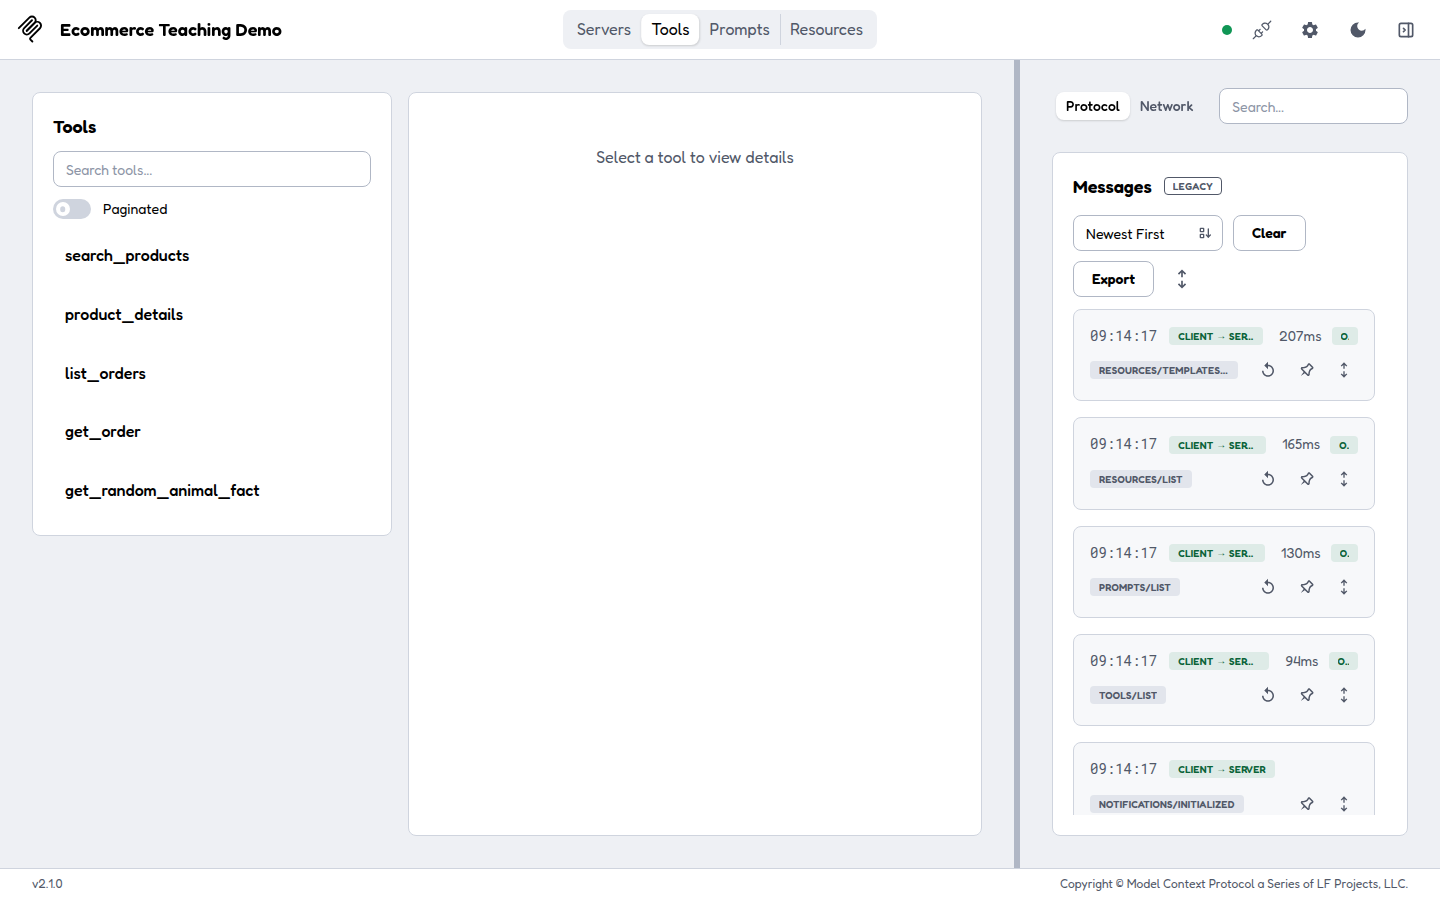

### Discover tools with the Python SDK

Open the streamable HTTP transport, initialize the session, and
list the tool catalog once. This is still instructor-only: the
direct client inspects capabilities but does not call a tool.

In [ ]:
from mcp import ClientSession
from mcp.client.streamable_http import streamable_http_client

MCP_ENDPOINT = 'https://walmart-demo-api-k2yx3oubha-ue.a.run.app/mcp'


async def discover_mcp_tools():
    async with streamable_http_client(MCP_ENDPOINT) as (
        read_stream,
        write_stream,
        _,
    ):
        async with ClientSession(read_stream, write_stream) as session:
            await session.initialize()
            result = await session.list_tools()
            return [
                {"name": tool.name, "description": tool.description or ""}
                for tool in result.tools
            ]


discovered_tools = await discover_mcp_tools()
discovered_tools

### 🔌 Step 1 — direct Order MCP tools

Build a canonical order agent with the prepared helper. The visible
part is small: instructions plus `list_orders` and `get_order`.

In [ ]:
order_mcp_toolset = load_order_mcp_tools()
order_mcp_agent = Agent(
    name="order_mcp_agent",
    model=GOOGLE_MODEL,
    instruction=(
        "Answer factual order questions with the available MCP tools. "
        "Use returned records only and state when data is missing."
    ),
    tools=[order_mcp_toolset],
)
order_mcp_runner = make_workshop_runner(
    order_mcp_agent,
    "orders_mcp_agent_workshop",
)

#### ▶️ Run the fixed Order request

Predict two calls: list summaries, then retrieve the selected record.

In [ ]:
ORDER_PROMPT = "Find my most recent order from July 1 through July 31, 2026. Tell me its status, total, and every item's name and quantity."
_ = await run_traced_turn(
    trace_name="05-01-order-mcp-agent",
    runner=order_mcp_runner,
    prompt=ORDER_PROMPT,
    session_id="05-01-order-mcp-agent",
)

#### Flush and inspect the direct Order MCP trace

Flush batching before opening Phoenix. In the trace, identify the
model decision, every tool boundary, and the evidence returned to the
final response.

In [ ]:
tracer_provider.force_flush()
print("Flushed direct Order MCP trace to Phoenix project", PROJECT_NAME)

#### 🔎 Trace review — Direct Order MCP

**What to notice**

- The agent sees `list_orders` and `get_order`, calls them in sequence, and makes another model decision after each tool result.
- The intermediate results return through agent context before the final answer. In this captured run, the final call shows 2,920 tokens, about 3 seconds, and less than $0.01; treat these as one trace, not a benchmark.

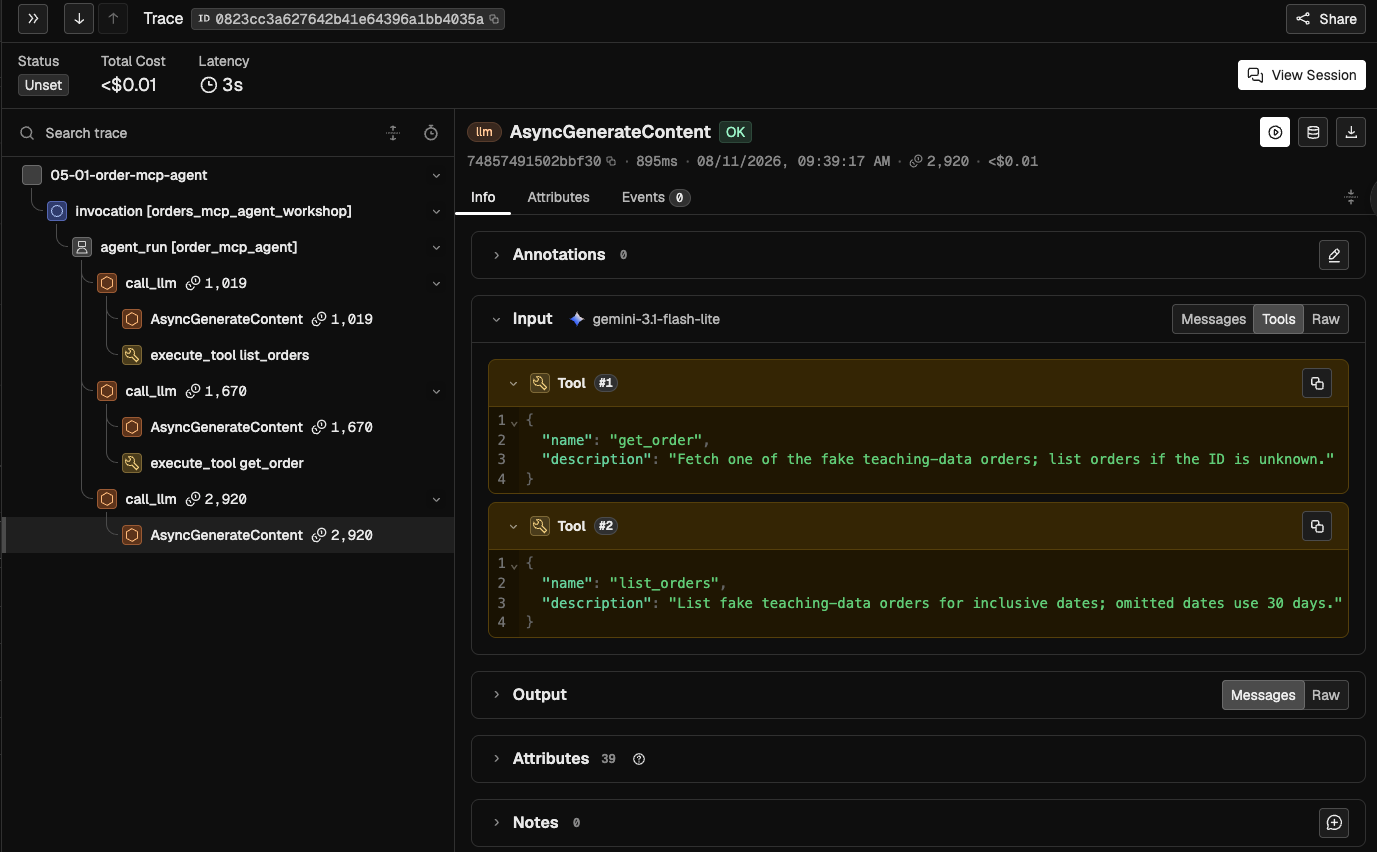

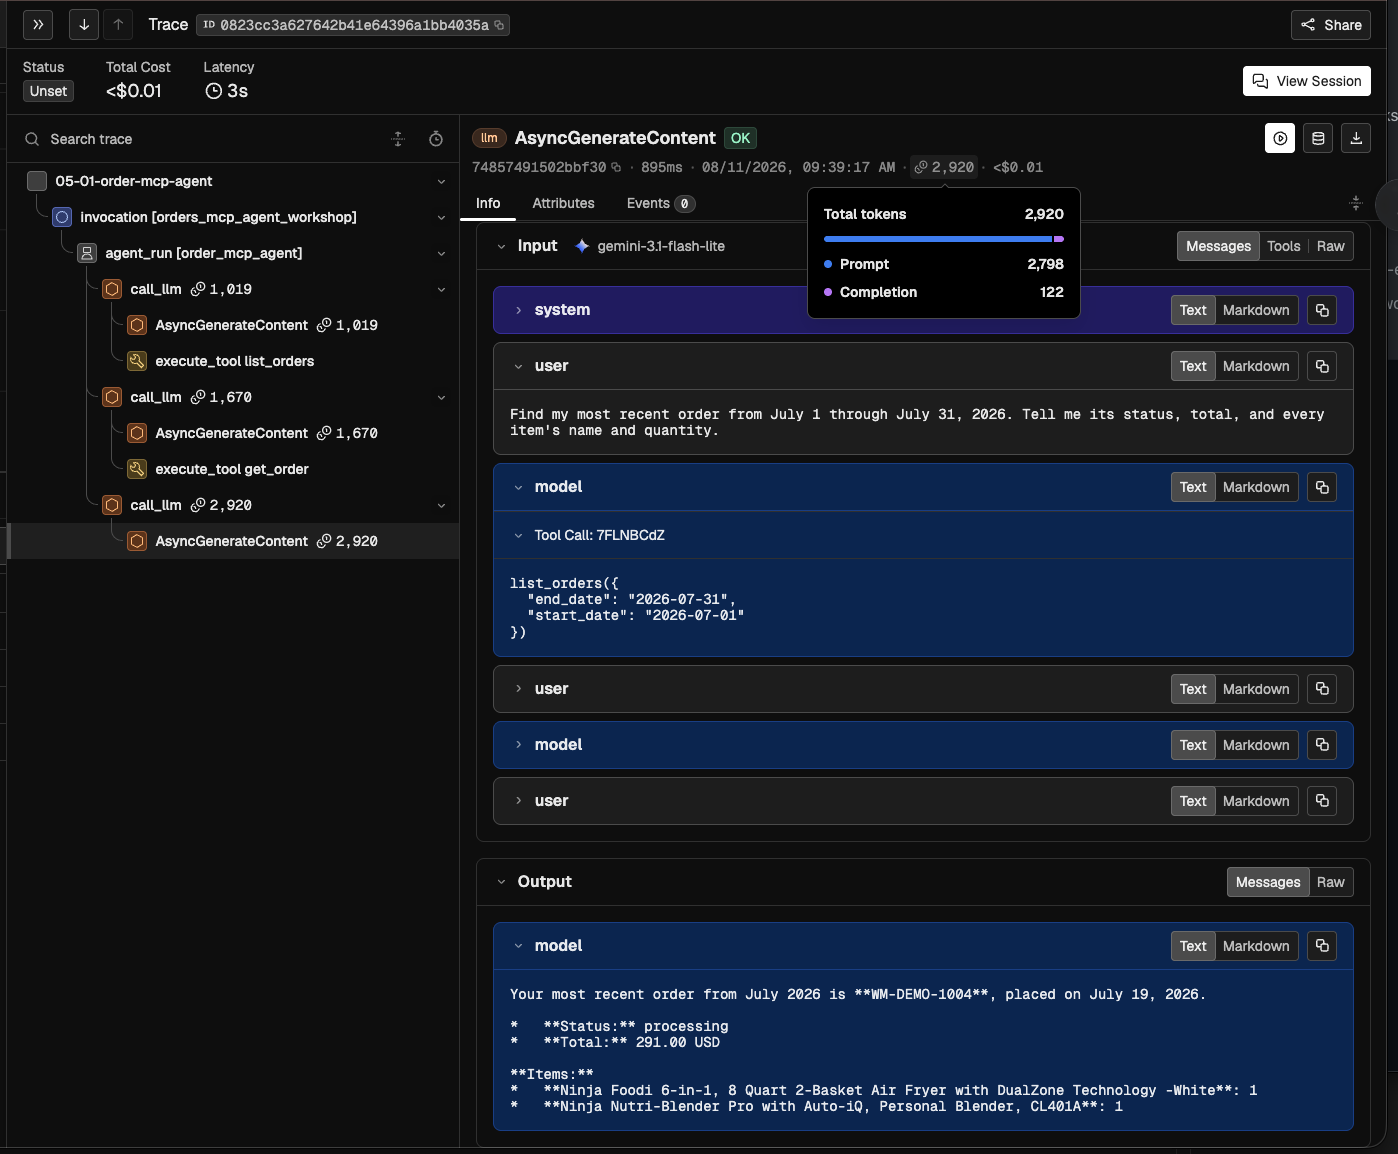

### 🧑‍💻 Step 2 — Order MCP Code

Run the same order task through one generated program. The agent sees
one `execute` tool. Inside the bounded execution it calls
`list_orders`, preserves a returned ID, and then calls `get_order`.
Intermediate payloads stay inside execution; one final result returns.

In [ ]:
order_code_toolset = load_order_code_tools()
order_code_agent = Agent(
    name="order_code_agent",
    model=GOOGLE_MODEL,
    instruction=(
        "Help customers answer questions about their orders. Use execute "
        "once with a short Python program. Inside the program, call "
        "list_orders first, select an ID only from those results, and call "
        "get_order for full details. End the program with return; never print. "
        "Report missing information plainly."
    ),
    tools=[order_code_toolset],
)
order_code_runner = make_workshop_runner(
    order_code_agent,
    "orders_code_mode_workshop",
)

#### ▶️ Run the same request through one execution tool

Keep the user request unchanged so the trace comparison is fair.

In [ ]:
_ = await run_traced_turn(
    trace_name="05-02-order-code-agent",
    runner=order_code_runner,
    prompt=ORDER_PROMPT,
    session_id="05-02-order-code-agent",
)

#### Flush and inspect the Order MCP Code trace

Flush batching before opening Phoenix. In the trace, identify the
model decision, every tool boundary, and the evidence returned to the
final response.

In [ ]:
tracer_provider.force_flush()
print("Flushed Order MCP Code trace to Phoenix project", PROJECT_NAME)

#### 🔎 Trace review — Order MCP Code

**What to notice**

- The agent sees one `execute` schema, writes one bounded program, and receives one final execution result instead of routing every internal payload through its own loop.
- Fewer calls do not guarantee correctness. This generated program reads `product_name`, while the returned item field is `name`, so the answer misses item names. Clear schemas, instructions, traces, and evaluations still matter.
The trace makes clear why fewer calls do not guarantee correctness: the field mismatch drops the item names.

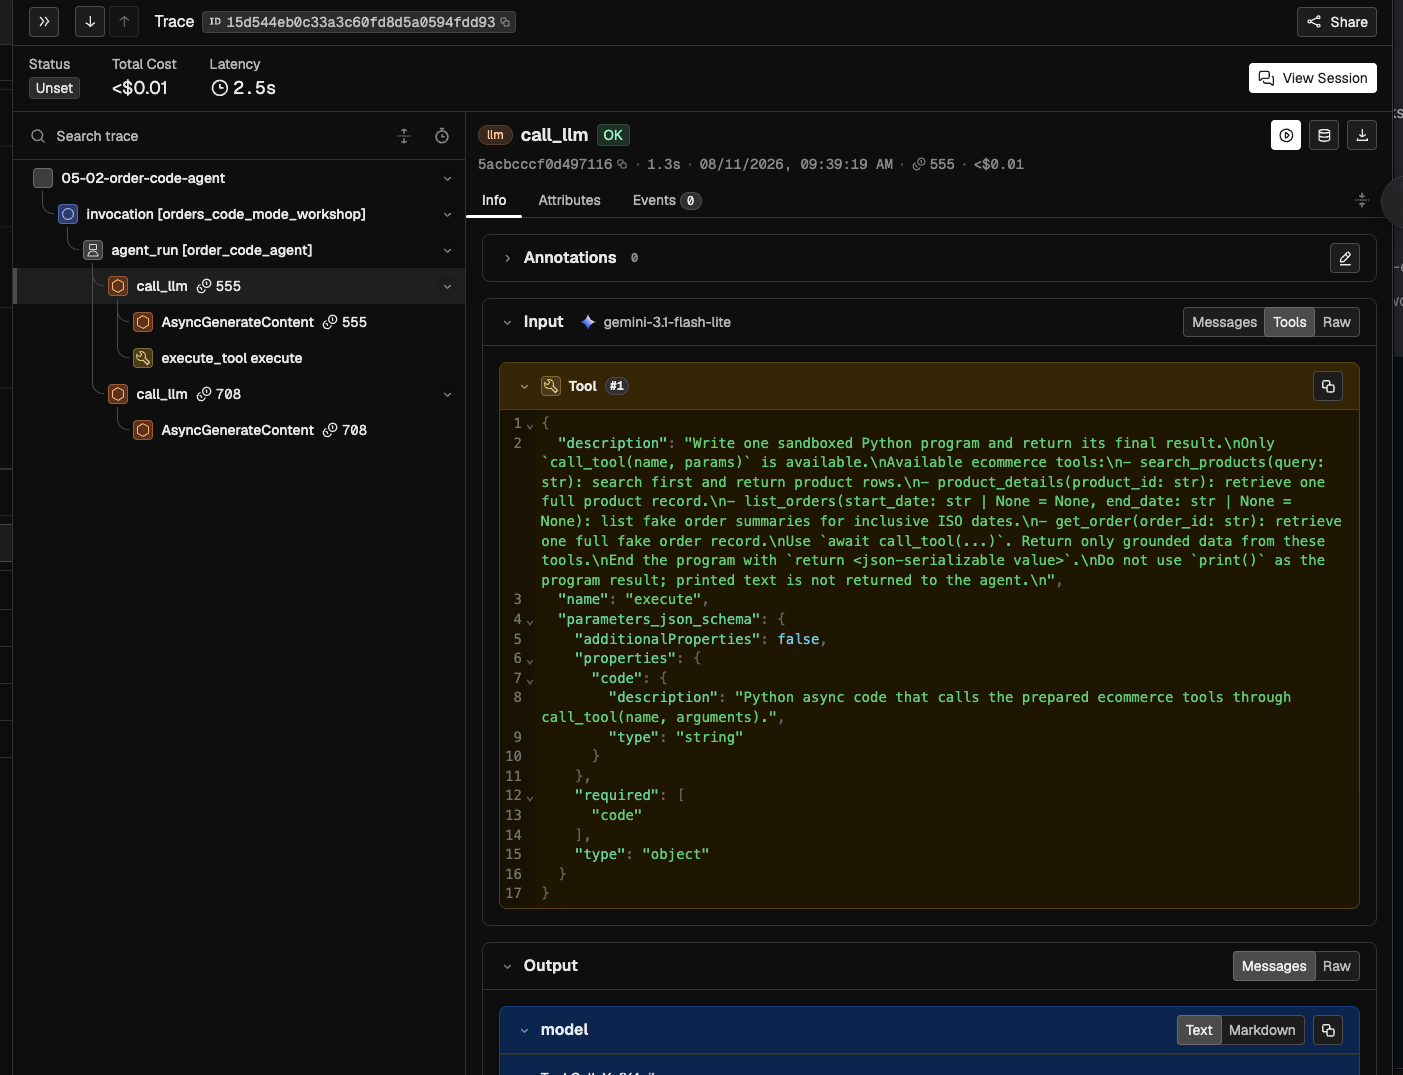

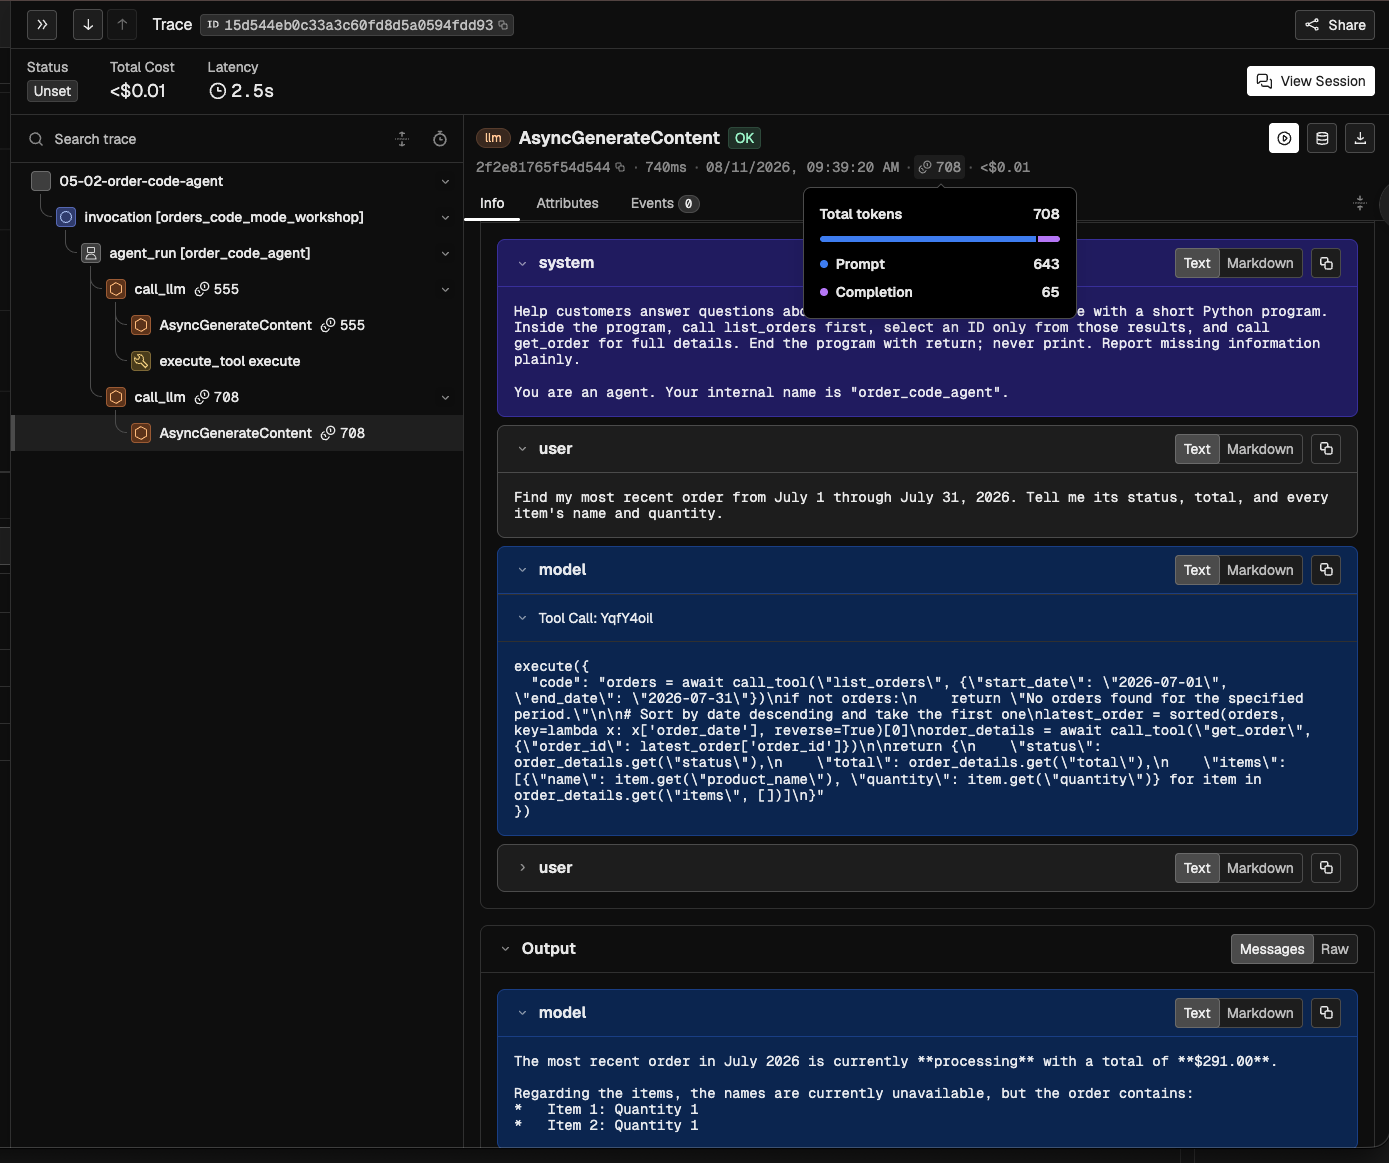

### 📘 Step 3 — Order Skill

Display the prepared order-support Skill. Its Markdown captures the
reusable list-before-details procedure and grounding rules.

In [ ]:
from IPython.display import Markdown, display

display(
    Markdown(skill_preview_markdown(
        repository_root / "skills" / "order-support"
    ))
)

#### Connect the prepared Skill

The helper supplies the Skill and its two activated Order tools.

In [ ]:
order_skill_toolset = load_order_skill_tools()
order_skill_agent = Agent(
    name="order_skill_agent",
    model=GOOGLE_MODEL,
    instruction=(
        "Use the available order-support skill for order questions. "
        "Follow its procedure and ground every factual claim."
    ),
    tools=[order_skill_toolset],
)
order_skill_runner = make_workshop_runner(
    order_skill_agent,
    "orders_skill_mcp_workshop",
)

#### ▶️ Run the Skill-backed agent

Look for Skill loading before the grounded Order tool calls.

In [ ]:
_ = await run_traced_turn(
    trace_name="05-03-order-skill-agent",
    runner=order_skill_runner,
    prompt=ORDER_PROMPT,
    session_id="05-03-order-skill-agent",
)

#### Flush and inspect the Order Skill trace

Flush batching before opening Phoenix. In the trace, identify the
model decision, every tool boundary, and the evidence returned to the
final response.

In [ ]:
tracer_provider.force_flush()
print("Flushed Order Skill trace to Phoenix project", PROJECT_NAME)

#### 🔎 Trace review — Order Skill

**What to notice**

- The trace shows lightweight discovery with `list_skills`, on-demand activation with `load_skill`, and then the focused Order tools.
- The procedure loads on demand, but first-time activation adds model and tool work. In this captured run, the final call reaches 4,322 tokens; compare behavior and context, not only the token total.

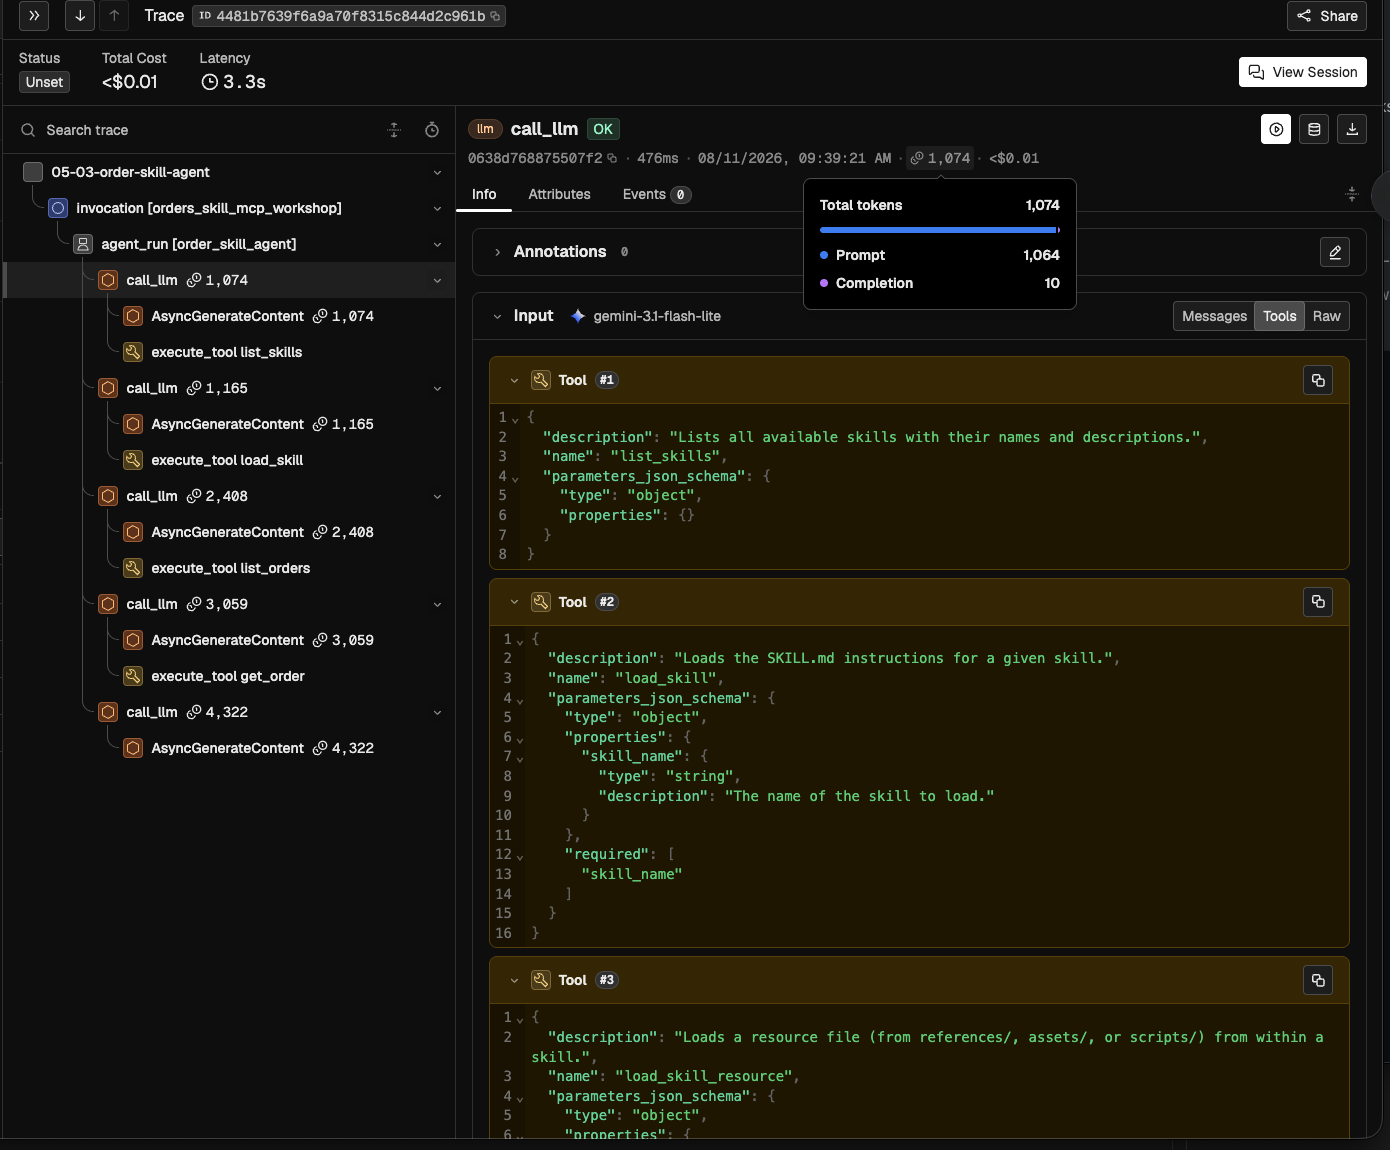

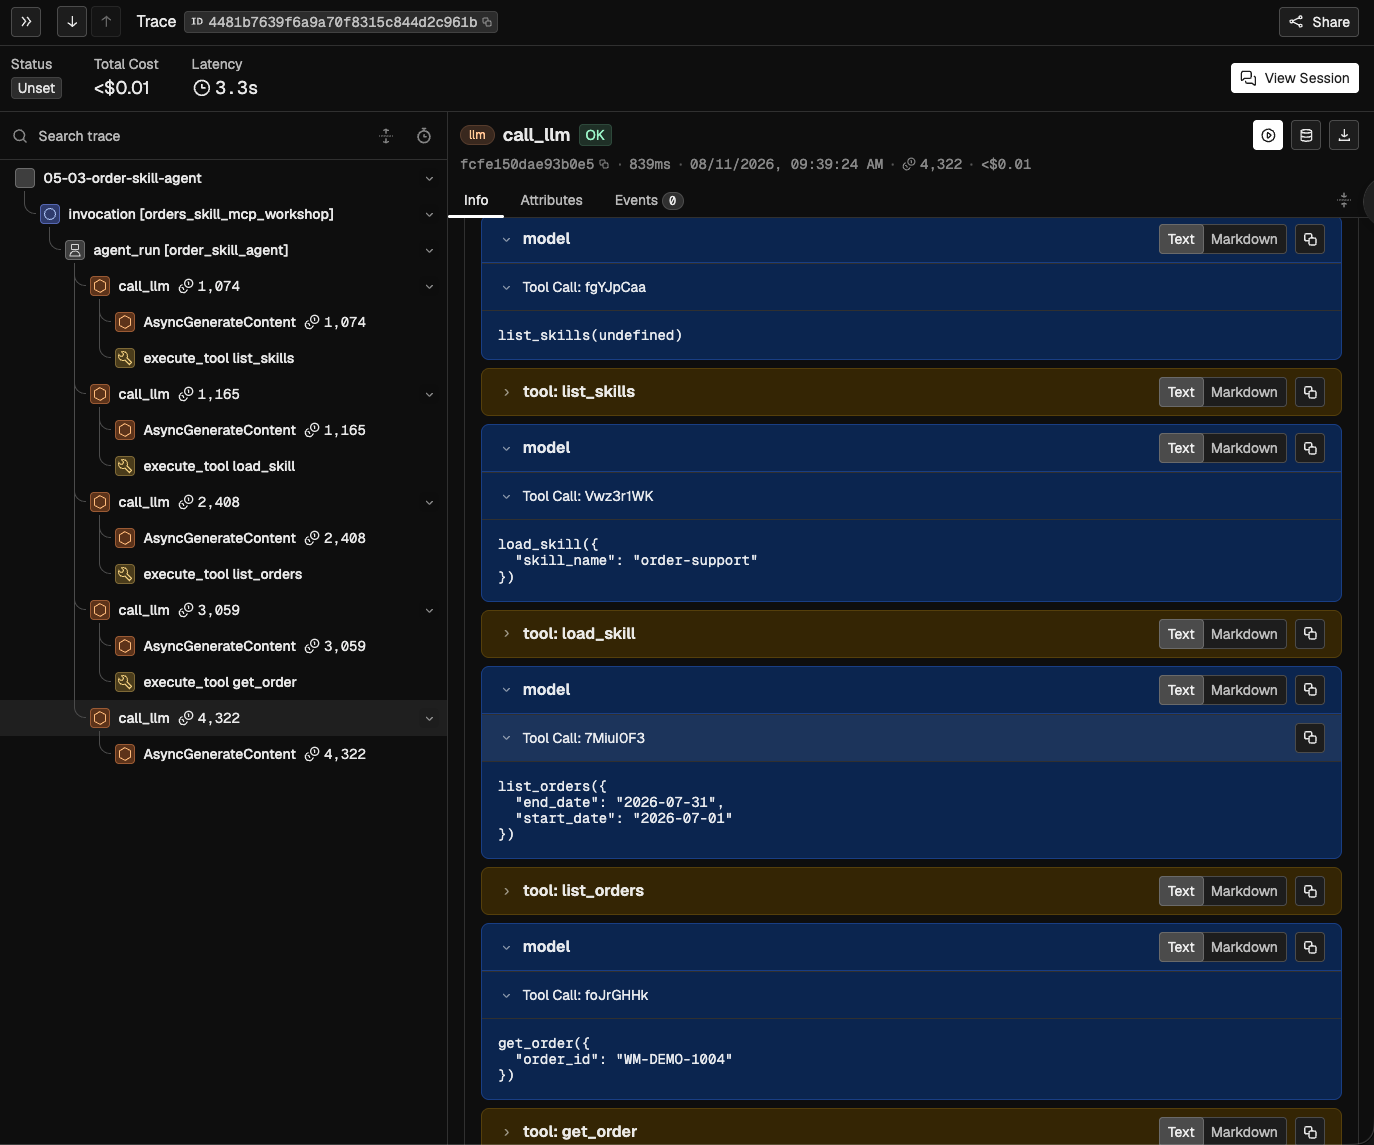

## Checks

| Trace | What to notice |
| --- | --- |
| `05-01-order-mcp-agent` | Two direct MCP tool schemas and calls. |
| `05-02-order-code-agent` | One execute call and one returned result. |
| `05-03-order-skill-agent` | Skill procedure plus activated Order tools. |

Compare model calls, tool arguments, context growth, and token usage.

In [ ]:
await close_workshop_tools()
print("🧹 Workshop MCP connections closed.")

## Next Steps

Notebook 06 compares two ways to compose ecommerce capabilities:
one agent with Skills and one parent with specialist subagents.